<a href="https://colab.research.google.com/github/SIDDI-NEHA-SREE/TEKWORKS/blob/main/Tw(30-05-26)1/notebooks/churn_prediction_eda_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup Dependencies and Download Dataset
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Fetch dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_path)
print("Data loaded successfully! Shape:", df.shape)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Data loaded successfully! Shape: (7043, 21)


/tmp/ipykernel_1026/1250117187.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='magma')


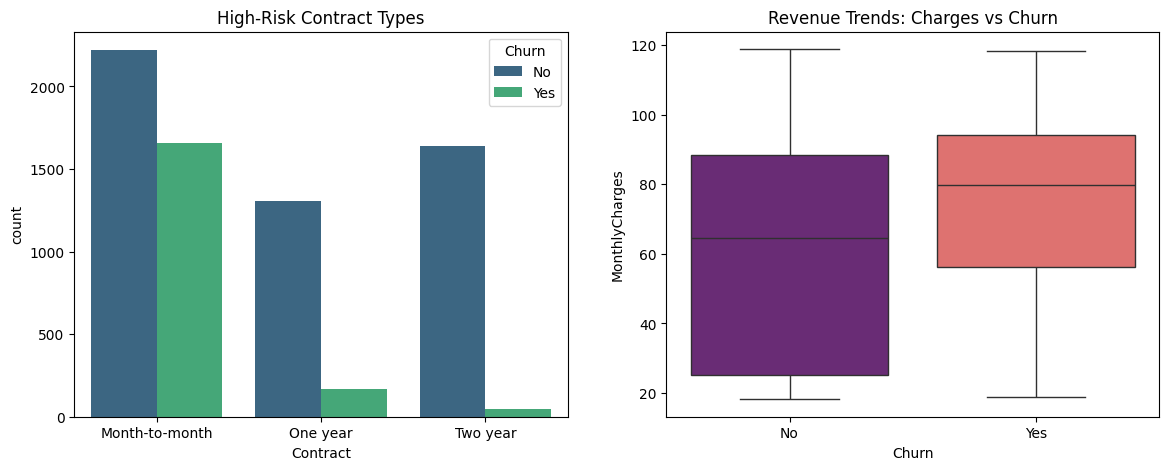

Preprocessing Complete.


In [2]:
# Cell 2: Phase 1 - Clean & Perform EDA
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Quick EDA Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('High-Risk Contract Types')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='magma')
axes[1].set_title('Revenue Trends: Charges vs Churn')
plt.show()

# Encode categorical metrics
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Preprocessing Complete.")

In [3]:
# Cell 3: Phase 2 & 3 - Build ANN & Run Layer Experiments
def build_and_train_ann(layers_config, X_train, y_train, X_test, y_test):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.2))

    for neurons in layers_config:
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)

    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    return model, {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

experiments = {
    "2_Hidden_Layers": [32, 16],
    "3_Hidden_Layers": [32, 16, 8],
    "5_Hidden_Layers": [64, 32, 16, 8, 4]
}

results = {}
for name, config in experiments.items():
    print(f"Training architecture variant: {name}...")
    model, metrics = build_and_train_ann(config, X_train, y_train, X_test, y_test)
    results[name] = metrics
    model.save(f"{name}.h5")
    print(f"{name} successfully saved to local directory.")

df_results = pd.DataFrame(results).T
print("\n====== Experiment Metrics ======")
print(df_results)

Training architecture variant: 2_Hidden_Layers...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


2_Hidden_Layers successfully saved to local directory.
Training architecture variant: 3_Hidden_Layers...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


3_Hidden_Layers successfully saved to local directory.
Training architecture variant: 5_Hidden_Layers...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


5_Hidden_Layers successfully saved to local directory.

====== Experiment Metrics ======
                 Accuracy  Precision    Recall
2_Hidden_Layers  0.783227   0.610932  0.508021
3_Hidden_Layers  0.779673   0.611888  0.467914
5_Hidden_Layers  0.777541   0.584488  0.564171
